In [2]:
from PIL import Image
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import glob
import random
from typing import List
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from datasets import load_dataset
from skimage.metrics import peak_signal_noise_ratio, structural_similarity


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CROP_SIZE = 33
lr = 1e-5
num_epochs = 3500
batch_size = 32


/Users/stefansrjakovferi/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/stefansrjakovferi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
class OnFlyDataset(Dataset):
    def __init__(self, root_dir: str, scale: int = None):
        self.root_dir = root_dir
        self.scale = scale

        exts = ("*.png",)
        image_paths: List[str] = []
        for ext in exts:
            image_paths.extend(glob.glob(os.path.join(root_dir, ext)))

        self.image_paths = sorted(image_paths)

        if len(self.image_paths) == 0:
            raise RuntimeError(f"No images found in {root_dir}")


    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        scale = self.scale if self.scale is not None else random.choice([2, 3])

        path = self.image_paths[idx]

        hr_img = Image.open(path).convert("RGB")

        lr_img = make_low_resolution(hr_img, scale)

        hr_y = rgb_to_y(hr_img)
        lr_y = rgb_to_y(lr_img)

        lr_crop, hr_crop = random_crop_pair(lr_y, hr_y, crop_size=CROP_SIZE)

        lr_tensor = torch.from_numpy(lr_crop).unsqueeze(0) / 255.0
        hr_tensor = torch.from_numpy(hr_crop).unsqueeze(0) / 255.0

        return lr_tensor, hr_tensor

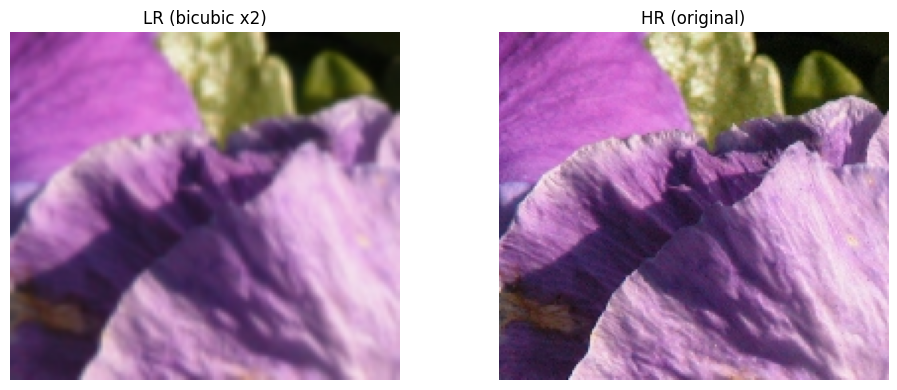

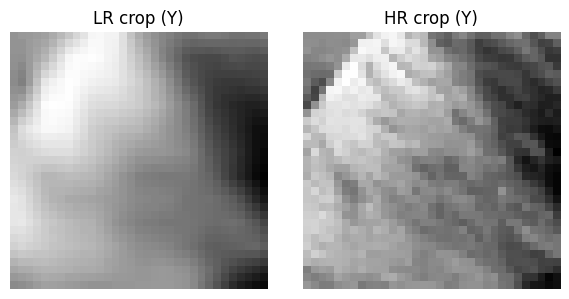

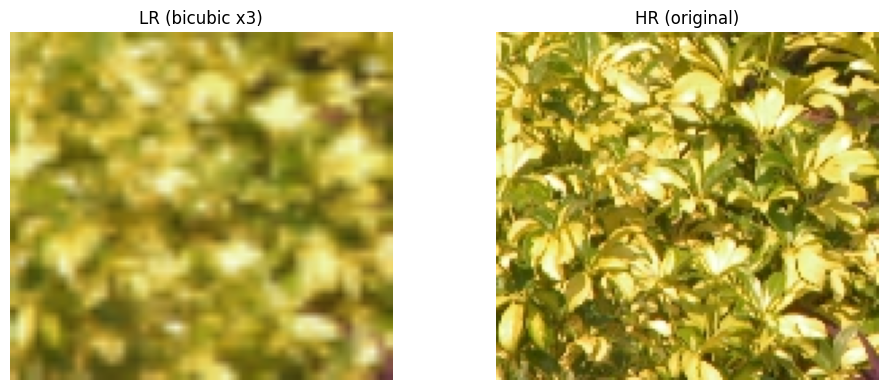

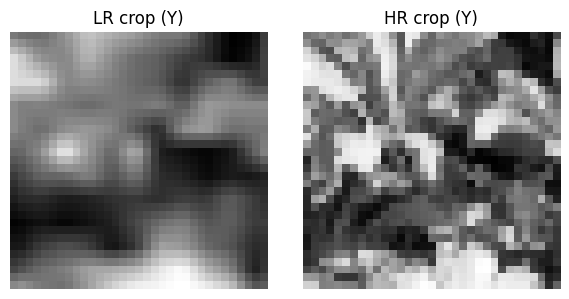

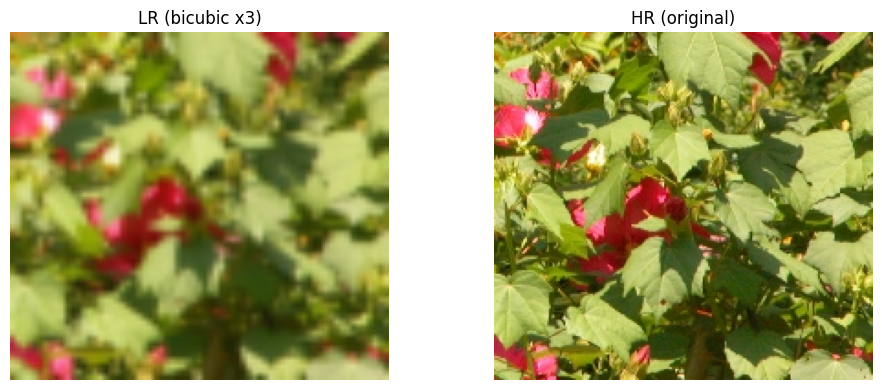

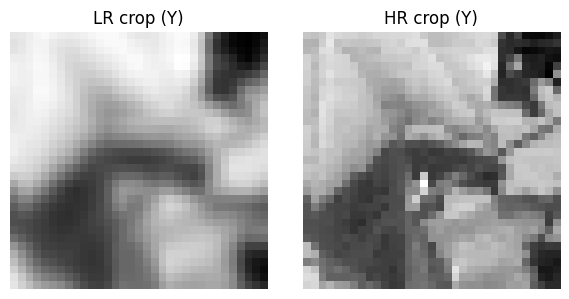

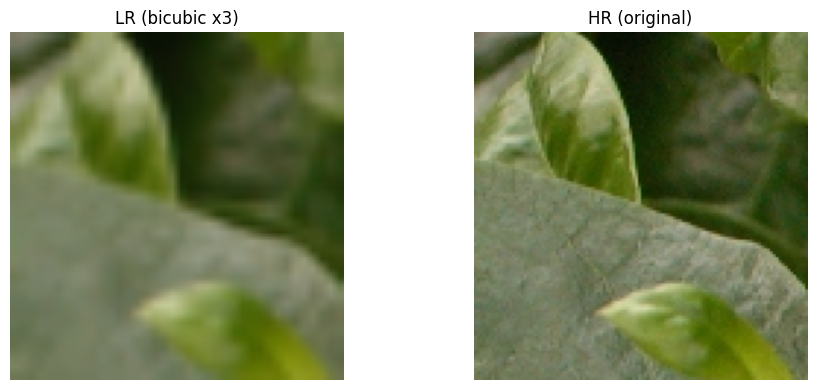

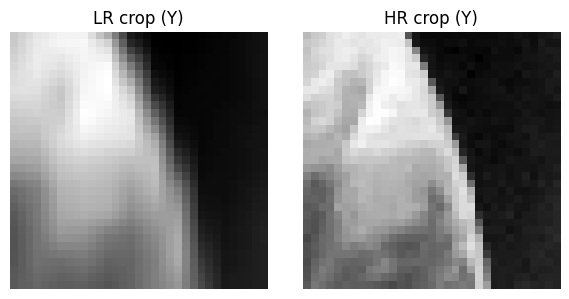

In [5]:
test_dataset = OnFlyDataset(root_dir="./T91", scale=None)
visualize_dataset_sample(test_dataset, idx=0)
visualize_dataset_sample(test_dataset, idx=1)
visualize_dataset_sample(test_dataset, idx=2)
visualize_dataset_sample(test_dataset, idx=3)

In [ ]:
dataset = OnFlyDataset("./T91")

widths = []
heights = []

for file in os.listdir("./T91"):
    if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
        img = Image.open(os.path.join("./T91", file))
        w, h = img.size
        widths.append(w)
        heights.append(h)

print("Število slik:", len(widths))
print("Povprečna širina:", np.mean(widths))
print("Povprečna višina:", np.mean(heights))

Število slik: 91
Povprečna širina: 264.1208791208791
Povprečna višina: 203.58241758241758


In [9]:
class SuperResolutionSRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv3 = nn.Conv2d(32, 1, kernel_size=5, padding=2)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.conv3(x)
        return x


model = SuperResolutionSRCNN().to(device)
print(model)

SuperResolutionSRCNN(
  (conv1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (relu1): ReLU(inplace=True)
  (conv2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU(inplace=True)
  (conv3): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)


In [ ]:
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers = 4, pin_memory=True )

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

epoch_losses = []

counter = 0
for epoch in range(num_epochs):
    model.train()

    for lr_batch, hr_batch in loader:
        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)

        optimizer.zero_grad()
        pred = model(lr_batch)
        loss = criterion(pred, hr_batch)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        if counter % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - loss: {loss.item():.6f}")
        counter += 1

Epoch 1/3500 - loss: 0.270090
Epoch 51/3500 - loss: 0.045234
Epoch 101/3500 - loss: 0.021178
Epoch 151/3500 - loss: 0.019619


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3ec2d01da0>
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3ec2d01da0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1600, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.12/threading.py", line 1146, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/

Epoch 201/3500 - loss: 0.012320
Epoch 251/3500 - loss: 0.009937
Epoch 301/3500 - loss: 0.007731
Epoch 351/3500 - loss: 0.007584
Epoch 401/3500 - loss: 0.005411
Epoch 451/3500 - loss: 0.004751
Epoch 501/3500 - loss: 0.003457
Epoch 551/3500 - loss: 0.003064
Epoch 601/3500 - loss: 0.003769
Epoch 651/3500 - loss: 0.004208
Epoch 701/3500 - loss: 0.003934
Epoch 751/3500 - loss: 0.003435
Epoch 801/3500 - loss: 0.003504
Epoch 851/3500 - loss: 0.002931
Epoch 901/3500 - loss: 0.003222
Epoch 951/3500 - loss: 0.003219
Epoch 1001/3500 - loss: 0.002272
Epoch 1051/3500 - loss: 0.002832
Epoch 1101/3500 - loss: 0.002691
Epoch 1151/3500 - loss: 0.002863
Epoch 1201/3500 - loss: 0.003214
Epoch 1251/3500 - loss: 0.002079
Epoch 1301/3500 - loss: 0.002379
Epoch 1351/3500 - loss: 0.002449
Epoch 1401/3500 - loss: 0.002154
Epoch 1451/3500 - loss: 0.001985
Epoch 1501/3500 - loss: 0.002973
Epoch 1551/3500 - loss: 0.003060
Epoch 1601/3500 - loss: 0.002389
Epoch 1651/3500 - loss: 0.003385
Epoch 1701/3500 - loss: 0.

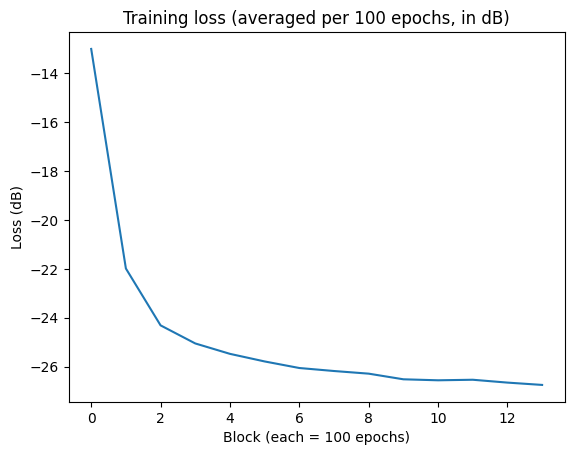

In [11]:

epoch_losses = np.array(epoch_losses)

N = 500
trim = len(epoch_losses) // N * N
loss_avg = epoch_losses[:trim].reshape(-1, N).mean(axis=1)

eps = 1e-12
loss_db = 10 * np.log10(loss_avg + eps)

plt.plot(loss_db)
plt.xlabel("Block (each = 100 epochs)")
plt.ylabel("Loss (dB)")
plt.title("Training loss (averaged per 100 epochs, in dB)")
plt.show()

In [14]:
state = torch.load("super_resolution_model.pth", map_location=device)
model.load_state_dict(state)
model.eval()

SuperResolutionSRCNN(
  (conv1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (relu1): ReLU(inplace=True)
  (conv2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU(inplace=True)
  (conv3): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)

In [18]:
ds = load_dataset("Voxel51/Set5", split="train")


Resolving data files:   0%|          | 0/138 [00:00<?, ?it/s]

Scale 2: MSE on Y = 0.001670
Scale 3: MSE on Y = 0.003983


/tmp/ipython-input-2210396050.py:47: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pred_y_img = Image.fromarray(pred_y_255, mode="L")
Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075

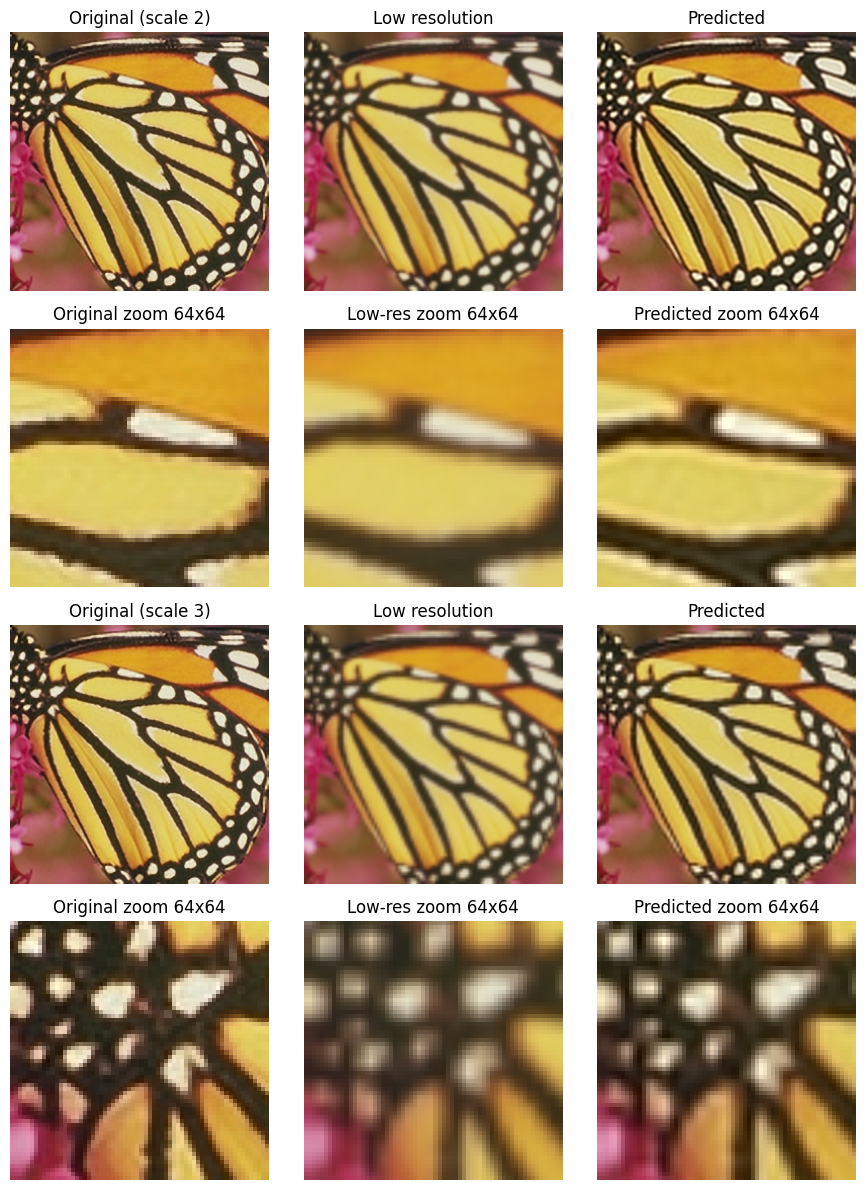

In [ ]:
if len(ds) == 0:
    raise RuntimeError("No images in dataset")

sample = random.choice(ds)
hr_img_rgb = sample["image"].convert("RGB")

model.eval()

scales = [2, 3]

fig, axes = plt.subplots(len(scales) * 2, 3, figsize=(9, 6 * len(scales)))

if len(scales) * 2 == 2:
    axes = np.array(axes).reshape(2, 3)

for i, scale in enumerate(scales):
    lr_img_rgb = make_low_resolution(hr_img_rgb, scale)

    hr_y = rgb_to_y(hr_img_rgb) / 255.0
    lr_y = rgb_to_y(lr_img_rgb) / 255.0

    lr_tensor = torch.from_numpy(lr_y).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_tensor = model(lr_tensor).clamp(0.0, 1.0)

    pred_y = pred_tensor.squeeze().cpu().numpy()

    mse = np.mean((hr_y - pred_y) ** 2)
    print(f"Scale {scale}: MSE on Y = {mse:.6f}")

    ycbcr_lr = lr_img_rgb.convert("YCbCr")
    _, cb_lr, cr_lr = ycbcr_lr.split()

    pred_y_255 = (pred_y * 255.0).clip(0, 255).astype(np.uint8)
    pred_y_img = Image.fromarray(pred_y_255, mode="L")
    pred_ycbcr_img = Image.merge("YCbCr", (pred_y_img, cb_lr, cr_lr))
    pred_rgb_img = pred_ycbcr_img.convert("RGB")

    row_full = 2 * i
    row_zoom = 2 * i + 1

    axes[row_full, 0].imshow(hr_img_rgb)
    axes[row_full, 0].set_title(f"Original (scale {scale})")
    axes[row_full, 0].axis("off")

    axes[row_full, 1].imshow(lr_img_rgb)
    axes[row_full, 1].set_title("Low resolution")
    axes[row_full, 1].axis("off")

    axes[row_full, 2].imshow(pred_rgb_img)
    axes[row_full, 2].set_title("Predicted")
    axes[row_full, 2].axis("off")

    w, h = hr_img_rgb.size
    crop_w, crop_h = 64, 64
    if w < crop_w or h < crop_h:
        x0, y0 = 0, 0
    else:
        x0 = random.randint(0, w - crop_w)
        y0 = random.randint(0, h - crop_h)
    box = (x0, y0, x0 + crop_w, y0 + crop_h)

    hr_crop = hr_img_rgb.crop(box)
    lr_crop = lr_img_rgb.crop(box)
    pred_crop = pred_rgb_img.crop(box)

    axes[row_zoom, 0].imshow(hr_crop)
    axes[row_zoom, 0].set_title("Original zoom 64x64")
    axes[row_zoom, 0].axis("off")

    axes[row_zoom, 1].imshow(lr_crop)
    axes[row_zoom, 1].set_title("Low-res zoom 64x64")
    axes[row_zoom, 1].axis("off")

    axes[row_zoom, 2].imshow(pred_crop)
    axes[row_zoom, 2].set_title("Predicted zoom 64x64")
    axes[row_zoom, 2].axis("off")

plt.tight_layout()
plt.show()

In [21]:
def evaluate_dataset_on_scale(dataset_name: str, scale: int):
    ds = load_dataset(dataset_name, split="train")

    psnr_lr_list = []
    ssim_lr_list = []
    psnr_pred_list = []
    ssim_pred_list = []

    for sample in ds:
        img = sample["image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)

        hr_img_rgb = img.convert("RGB")
        lr_img_rgb = make_low_resolution(hr_img_rgb, scale)

        hr_y = rgb_to_y(hr_img_rgb) / 255.0
        lr_y = rgb_to_y(lr_img_rgb) / 255.0

        lr_tensor = torch.from_numpy(lr_y).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            pred_tensor = model(lr_tensor).clamp(0.0, 1.0)

        pred_y = pred_tensor.squeeze().cpu().numpy()

        psnr_lr = peak_signal_noise_ratio(hr_y, lr_y, data_range=1.0)
        ssim_lr = structural_similarity(hr_y, lr_y, data_range=1.0)
        psnr_pred = peak_signal_noise_ratio(hr_y, pred_y, data_range=1.0)
        ssim_pred = structural_similarity(hr_y, pred_y, data_range=1.0)

        psnr_lr_list.append(psnr_lr)
        ssim_lr_list.append(ssim_lr)
        psnr_pred_list.append(psnr_pred)
        ssim_pred_list.append(ssim_pred)

    print(f"\nDataset: {dataset_name}, scale = {scale}")
    print("  Original vs LowRes:")
    print("    PSNR [dB] mean = {:.2f}, std = {:.2f}".format(
        np.mean(psnr_lr_list), np.std(psnr_lr_list)))
    print("    SSIM [-] mean = {:.4f}, std = {:.4f}".format(
        np.mean(ssim_lr_list), np.std(ssim_lr_list)))

    print("  Original vs Predicted:")
    print("    PSNR [dB] mean = {:.2f}, std = {:.2f}".format(
        np.mean(psnr_pred_list), np.std(psnr_pred_list)))
    print("    SSIM [-] mean = {:.4f}, std = {:.4f}".format(
        np.mean(ssim_pred_list), np.std(ssim_pred_list)))


In [23]:
print('Evaluate Set5 with scale 2')
evaluate_dataset_on_scale("Voxel51/Set5", scale=2)
print('Evaluate Set14 with scale 2')
evaluate_dataset_on_scale("Voxel51/Set14", scale=2)
print('Evaluate Set5 with scale 3')
evaluate_dataset_on_scale("Voxel51/Set5", scale=3)
print('Evaluate Set14 with scale 3')
evaluate_dataset_on_scale("Voxel51/Set14", scale=3)

Evaluate Set5 with scale 2


Resolving data files:   0%|          | 0/138 [00:00<?, ?it/s]


Dataset: Voxel51/Set5, scale = 2
  Original vs LowRes:
    PSNR [dB] mean = 32.25, std = 5.40
    SSIM [-] mean = 0.9299, std = 0.0564
  Original vs Predicted:
    PSNR [dB] mean = 35.09, std = 5.71
    SSIM [-] mean = 0.9533, std = 0.0392
Evaluate Set14 with scale 2


Resolving data files:   0%|          | 0/381 [00:00<?, ?it/s]


Dataset: Voxel51/Set14, scale = 2
  Original vs LowRes:
    PSNR [dB] mean = 31.07, std = 4.69
    SSIM [-] mean = 0.9064, std = 0.0773
  Original vs Predicted:
    PSNR [dB] mean = 34.15, std = 5.27
    SSIM [-] mean = 0.9435, std = 0.0539
Evaluate Set5 with scale 3


Resolving data files:   0%|          | 0/138 [00:00<?, ?it/s]


Dataset: Voxel51/Set5, scale = 3
  Original vs LowRes:
    PSNR [dB] mean = 29.25, std = 5.09
    SSIM [-] mean = 0.8744, std = 0.0862
  Original vs Predicted:
    PSNR [dB] mean = 32.50, std = 5.84
    SSIM [-] mean = 0.9215, std = 0.0671
Evaluate Set14 with scale 3


Resolving data files:   0%|          | 0/381 [00:00<?, ?it/s]


Dataset: Voxel51/Set14, scale = 3
  Original vs LowRes:
    PSNR [dB] mean = 28.29, std = 4.21
    SSIM [-] mean = 0.8414, std = 0.1091
  Original vs Predicted:
    PSNR [dB] mean = 31.44, std = 5.52
    SSIM [-] mean = 0.8982, std = 0.0907


In [5]:
def random_crop_pair(lr: np.ndarray, hr: np.ndarray, crop_size=33):
    h, w = lr.shape

    if h < crop_size or w < crop_size:
        raise ValueError("Image too small for cropping.")

    x = random.randint(0, w - crop_size)
    y = random.randint(0, h - crop_size)

    lr_crop = lr[y:y+crop_size, x:x+crop_size]
    hr_crop = hr[y:y+crop_size, x:x+crop_size]

    return lr_crop, hr_crop

def make_low_resolution(img: Image.Image, scale: int) -> Image.Image:
    w, h = img.size

    low_w = w // scale
    low_h = h // scale

    img_down = img.resize((low_w, low_h), Image.BILINEAR)

    img_up = img_down.resize((w, h), Image.BILINEAR)

    return img_up

def rgb_to_y(img: Image.Image) -> np.ndarray:
    ycbcr = img.convert("YCbCr")
    y, _, _ = ycbcr.split()
    return np.array(y, dtype=np.float32)


def visualize_dataset_sample(dataset: OnFlyDataset, idx: int = 0):
    img_path = dataset.image_paths[idx]
    scale = random.choice([2, 3])

    hr_rgb = Image.open(img_path).convert("RGB")
    lr_rgb = make_low_resolution(hr_rgb, scale)

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].imshow(lr_rgb)
    axs[0].set_title(f"LR (bicubic x{scale})")
    axs[0].axis("off")

    axs[1].imshow(hr_rgb)
    axs[1].set_title("HR (original)")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()

    lr_tensor, hr_tensor = dataset[idx]

    lr_crop = lr_tensor.squeeze(0).numpy()
    hr_crop = hr_tensor.squeeze(0).numpy()

    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(lr_crop, cmap="gray")
    axs[0].set_title("LR crop (Y)")
    axs[0].axis("off")

    axs[1].imshow(hr_crop, cmap="gray")
    axs[1].set_title("HR crop (Y)")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()
